In [1]:
from pathlib import Path

import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_quantile
from DiffFlowTransport.utils.plot import plot_PQET_ST, plot_PQET_ST2, plot_young_water
from DiffFlowTransport.model import load_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload
    

# Load models

In [4]:
model_names = [
    'mdn-gaussian-couplingtype1',
    'mdn-gaussian-couplingtype3',
    'mdn-gaussian-couplingtype4',
    'mdn-one_gamma-couplingtype1',
    'mdn-one_gamma-couplingtype3',
    'mdn-one_gamma-couplingtype4',
    'mdn-couplingtype1',
    'mdn-couplingtype3',
    'mdn-couplingtype4',
]

saved_folder = Path("./models-withDiffusion")

f_configs_set = [f'configs-{model}.json' for model in model_names]


In [6]:
model_set, loss_set, flow_dl_set, transport_data_set, configs_set = [], [], [], [], []
for f_configs in f_configs_set:
    model, loss, flow_dl, transport_data, configs = load_model(f_configs, saved_folder)
    model_set.append(model)
    loss_set.append(loss)
    flow_dl_set.append(flow_dl)
    transport_data_set.append(transport_data)
    configs_set.append(configs)


INFO:2025-03-04 15:14:19,670:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-04 15:14:19,670 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-03-04 15:14:19,726:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-03-04 15:14:19,726 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


# Plot loss

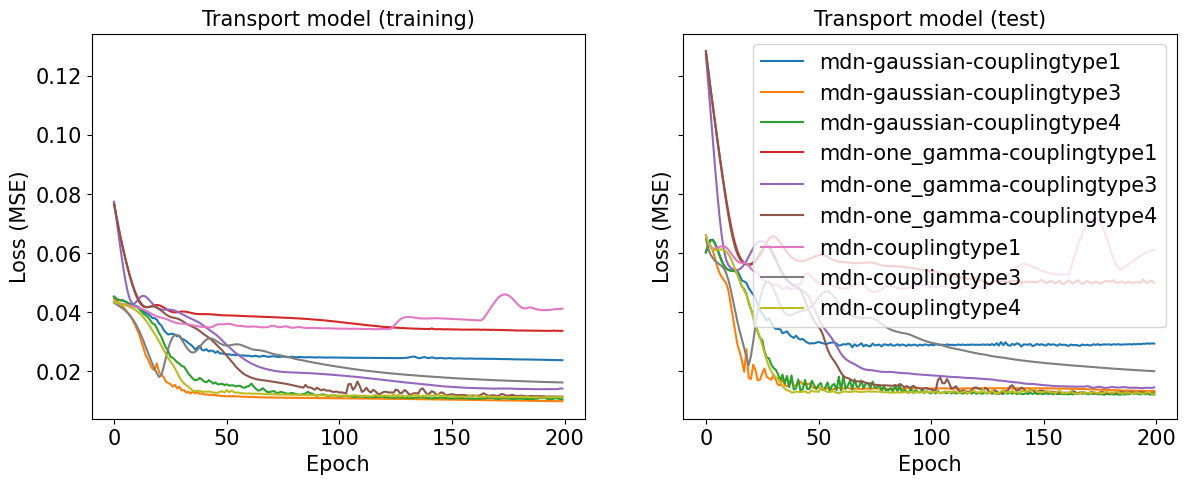

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
for i,loss in enumerate(loss_set):
    model_name = model_names[i]
    axes[0].plot(loss['transport_loss']['train'], label=model_name)
    axes[1].plot(loss['transport_loss']['test'], label=model_name)

for i,ax in enumerate(axes):
    ax.set(xlabel='Epoch', ylabel='Loss (MSE)', 
           title='Transport model (training)' if i==0 else 'Transport model (test)')
ax.legend()


In [12]:
# Run all the models
transport_output_set = []
transport_output_set_noQ = []
flow_output_set = []
for i,model in enumerate(model_set):
    print(model)
    flow_dl, transport_data = flow_dl_set[i], transport_data_set[i]
    J, Q, ET, C_J, C_Q_J, time = transport_data
    transport_output, _ = model.run_transport(J, C_J, ET, Q, dl=flow_dl)
    transport_output_noQ, Q_pred = model.run_transport(J, C_J, ET, Q=None, dl=flow_dl)
    flow_output_set.append(Q_pred)
    transport_output_set.append(transport_output)
    transport_output_set_noQ.append(transport_output_noQ)


In [13]:
df_set = []
for i,transport_data in enumerate(transport_data_set):
    J, Q, ET, C_J, C_Q, time = transport_data
    sT, mT, mQETs, pQETs, mRs, C_Q_pred = transport_output_set[i]
    C_Q_pred2 = transport_output_set_noQ[i][-1]
    Q_pred = flow_output_set[i]
    data = list(zip(J, Q, Q_pred.flatten(), ET, C_J.flatten(), 
                    C_Q.flatten(), C_Q_pred.flatten(), C_Q_pred2.flatten()))
    df = pd.DataFrame(data, columns=['J', 'Q', 'Q_simb', 'ET', 'C_J', 'C_Q', 'C_Q_sim', 'C_Q_simb']).astype(float)
    df.index = time
    df_set.append(df)


# Let's look at one model

In [15]:
i = -1
model_name, configs, df = model_names[i], configs_set[i], df_set[i]
sT, mT, mQETs, pQETs, mRs, C_Q = transport_output_set[i]
test_s, test_e = configs['train_configs']['test_start'], configs['train_configs']['test_end']
dt = configs['transport_configs']['transport_specs']['dt']
model_name


'mdn-couplingtype4'

In [16]:
df['Q'].max()

33.00719451904297

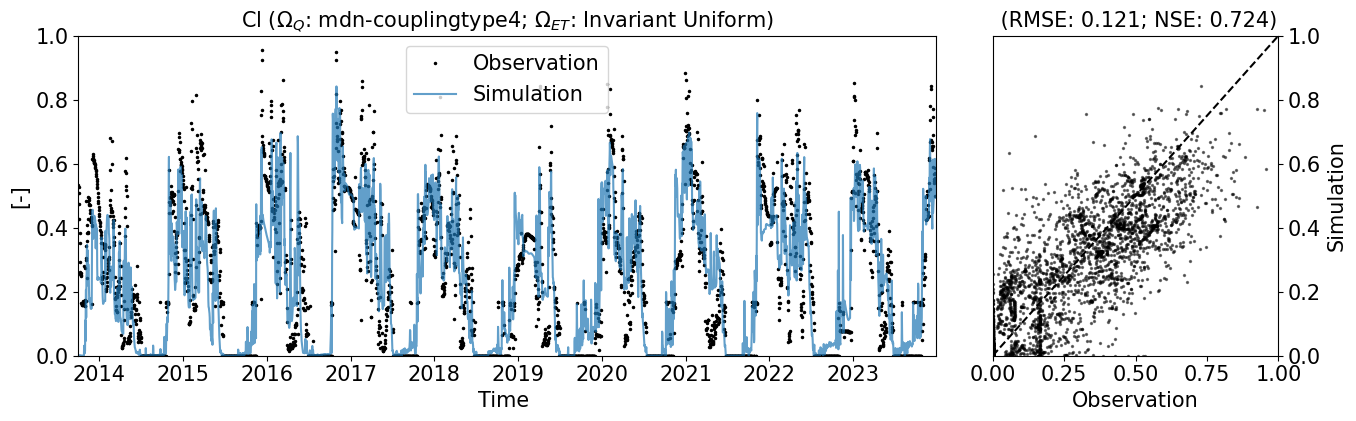

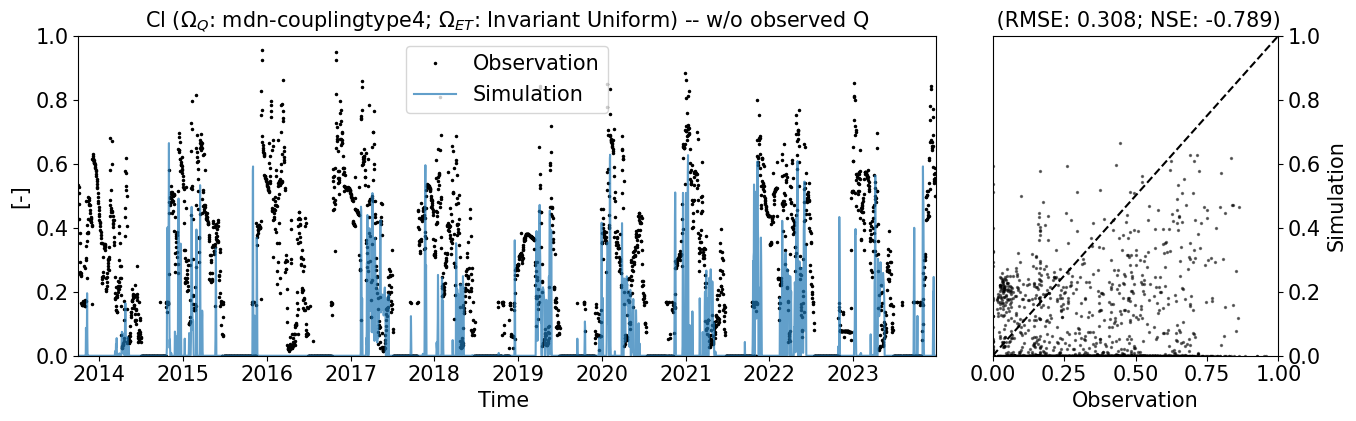

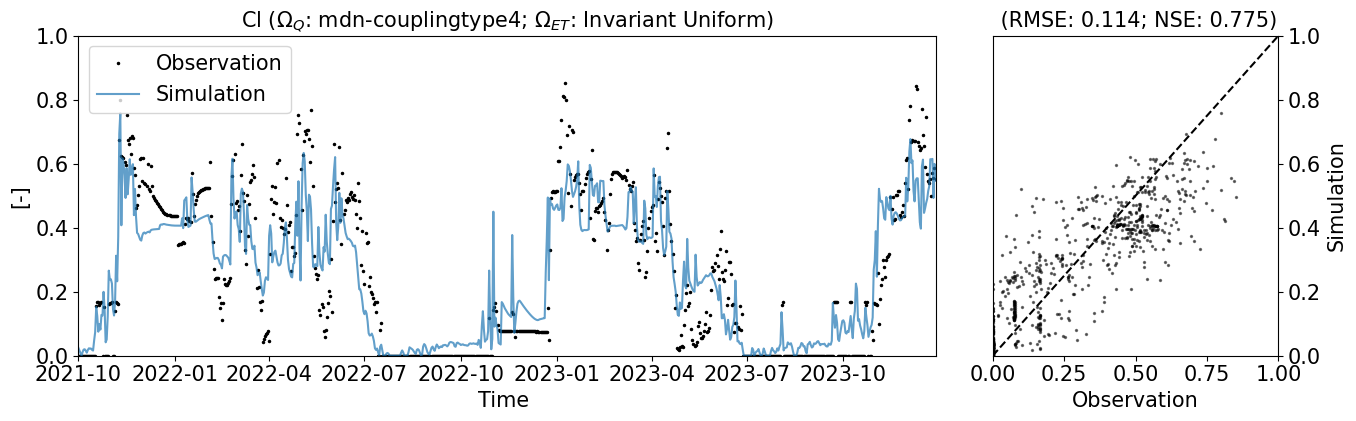

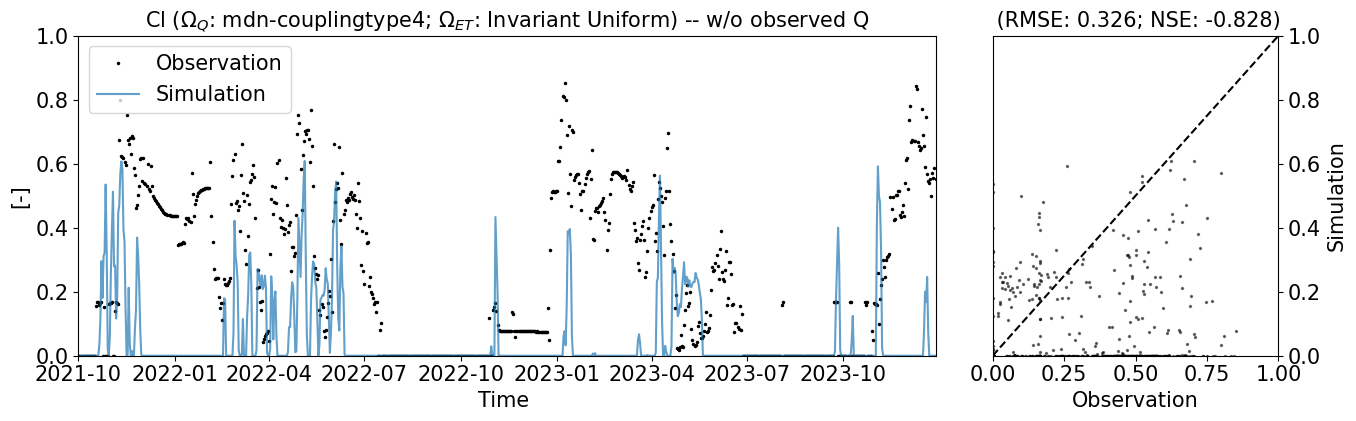

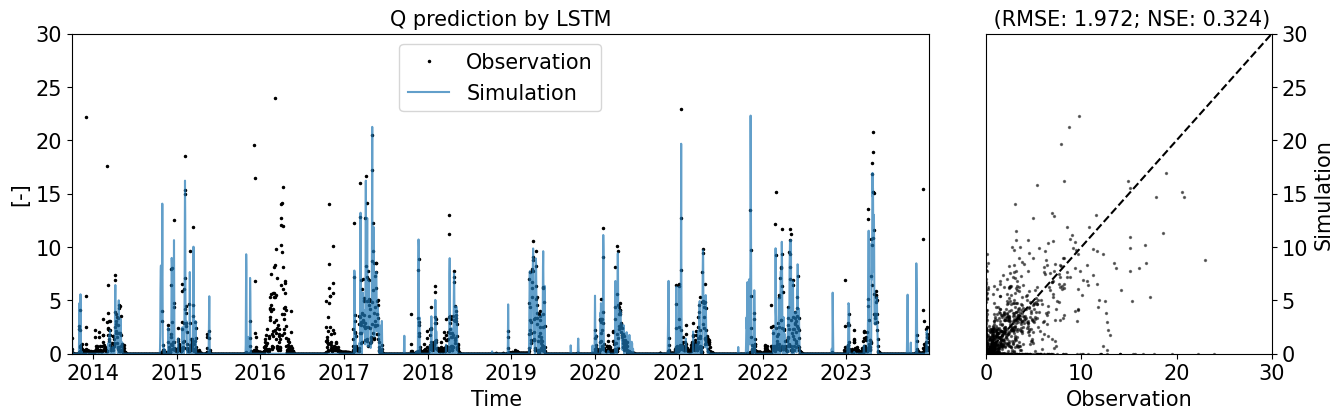

In [20]:
# Plot the C_J simulation
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_sim'].values, lim=[0,1], timesteps=df.index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_simb'].values, lim=[0,1], timesteps=df.index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
# Plot the C_J simulation
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_sim'].values, lim=[0,1], timesteps=df[test_s:test_e].index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_simb'].values, lim=[0,1], timesteps=df[test_s:test_e].index,
    varn=f'Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);

plot_timeseries_obs_1to1(
    obs=df['Q'].values, sim=df['Q_simb'].values, lim=[0,30], timesteps=df.index,
    varn='Q prediction by LSTM'
);


array([<Axes: title={'center': 'Q age distribution ()'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution ()'}, ylabel='Age [Days]'>],
      dtype=object)

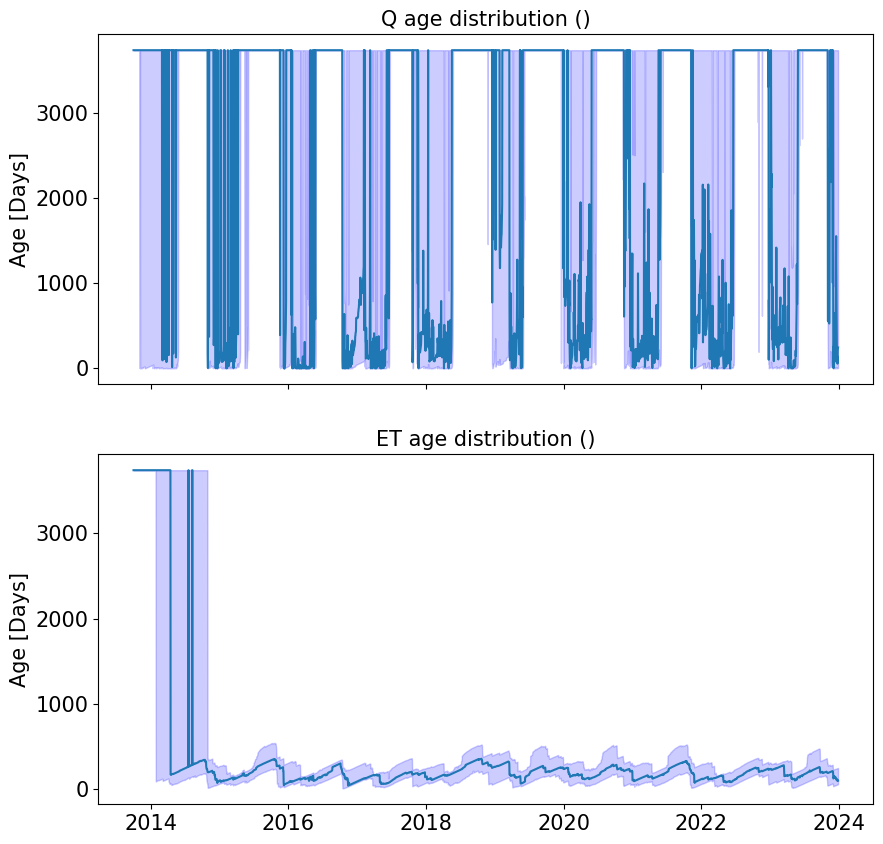

In [21]:
# Plot the age distribution
plot_PQET_quantile(pQETs, dt, time)


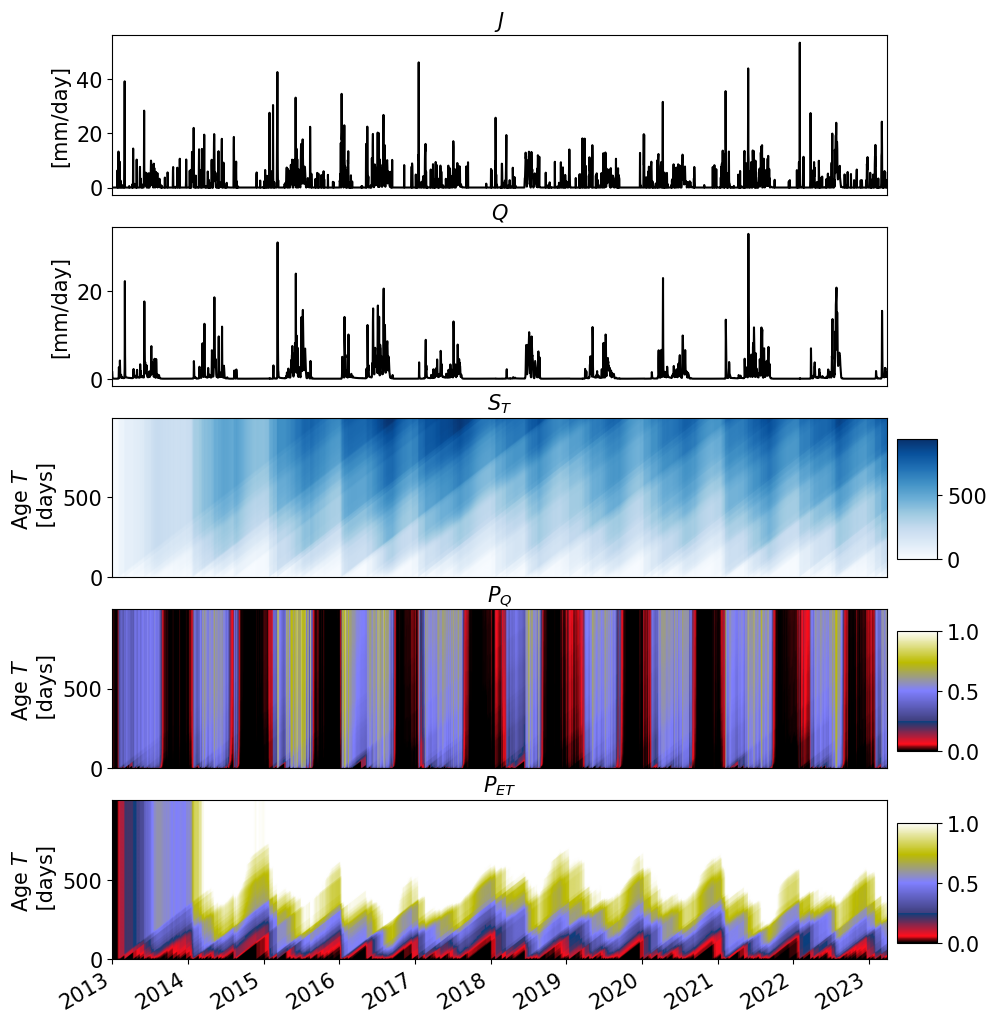

In [22]:
plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=1000);


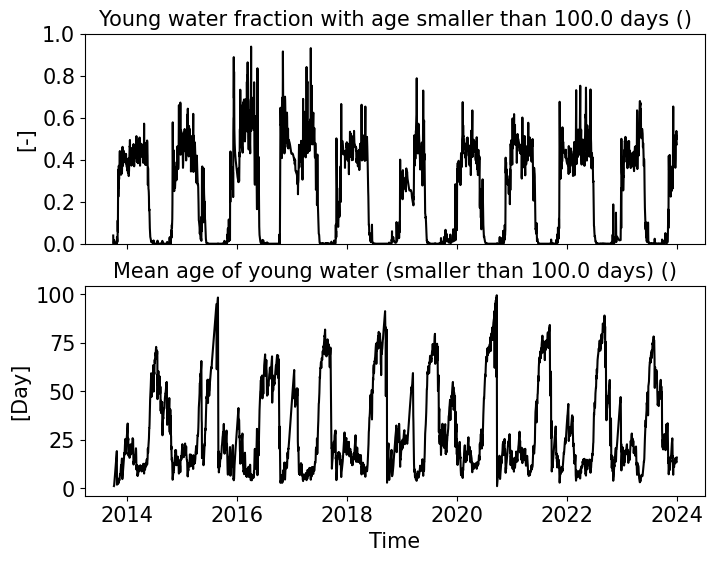

In [23]:
# Young water fraction in streamflow
plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=100);


# Model intercomparison

In [24]:
test_s, test_e = configs['train_configs']['test_start'], configs['train_configs']['test_end']
train_s, train_e = configs['train_configs']['train_start'], configs['train_configs']['train_end']
dt = configs['transport_configs']['transport_specs']['dt']


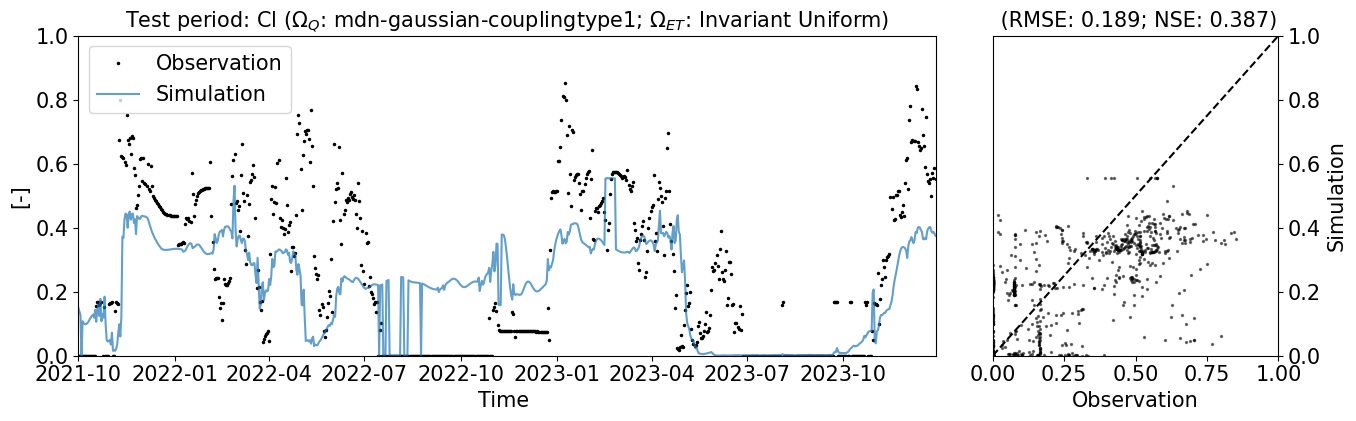

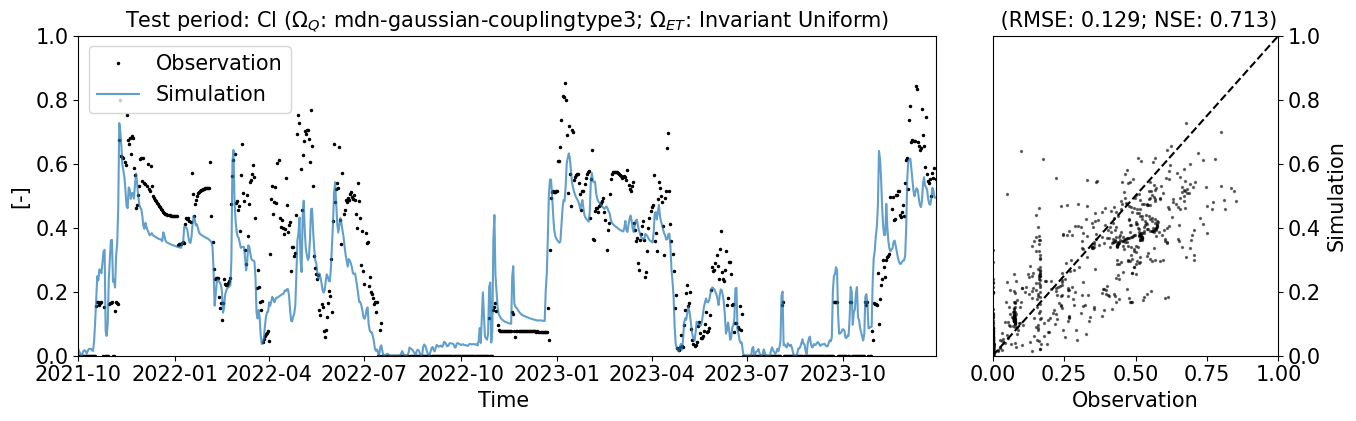

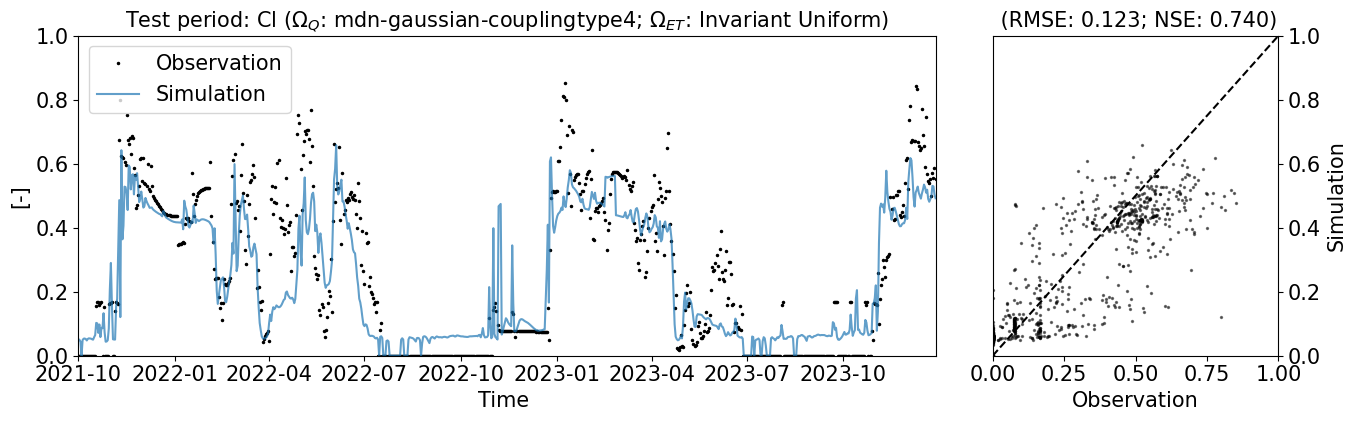

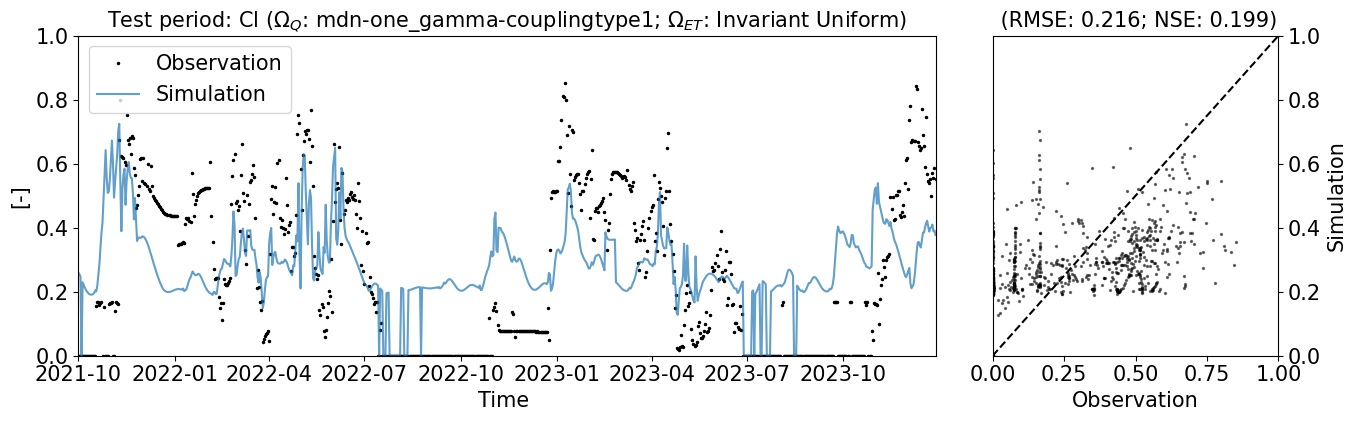

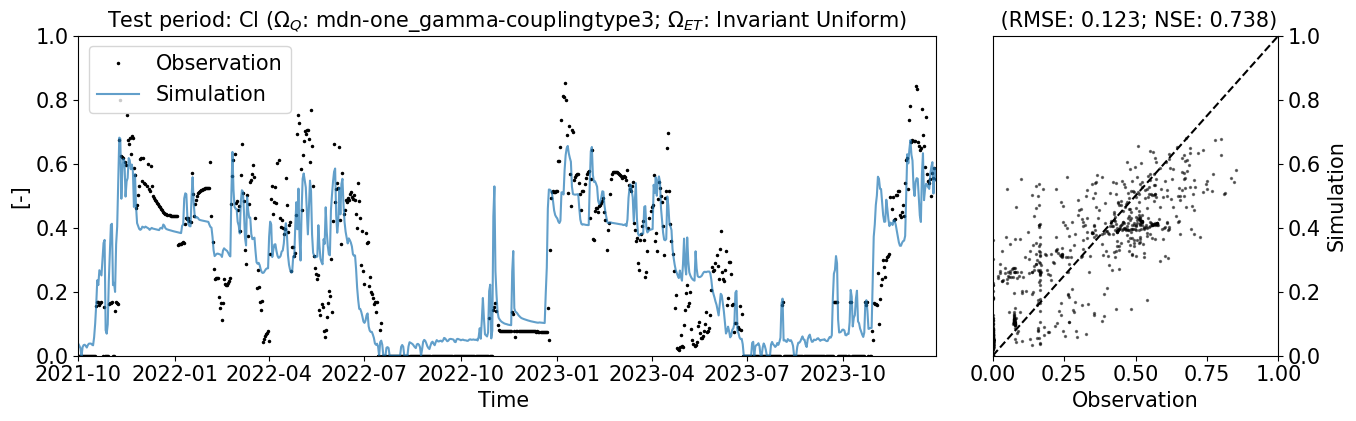

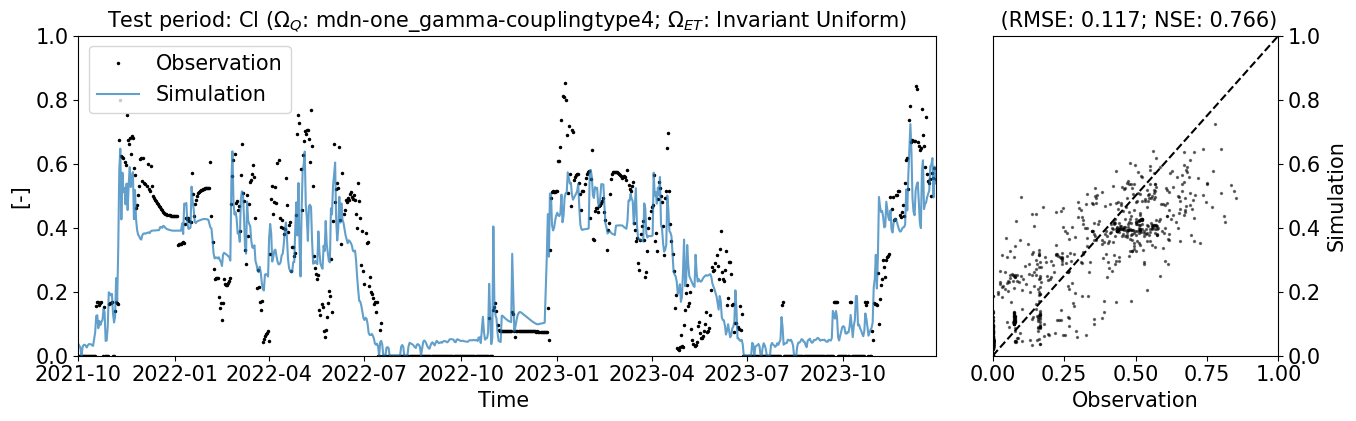

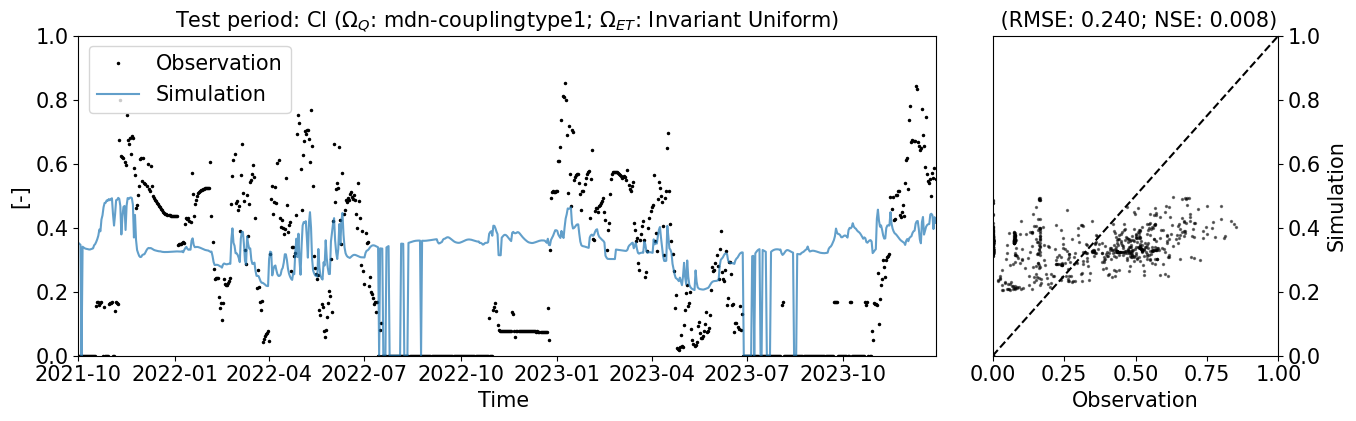

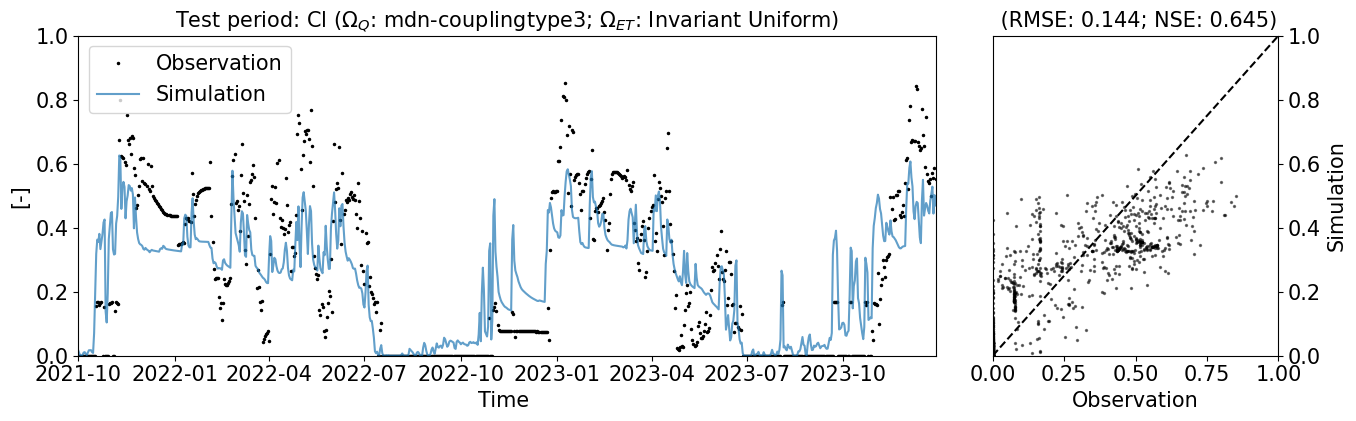

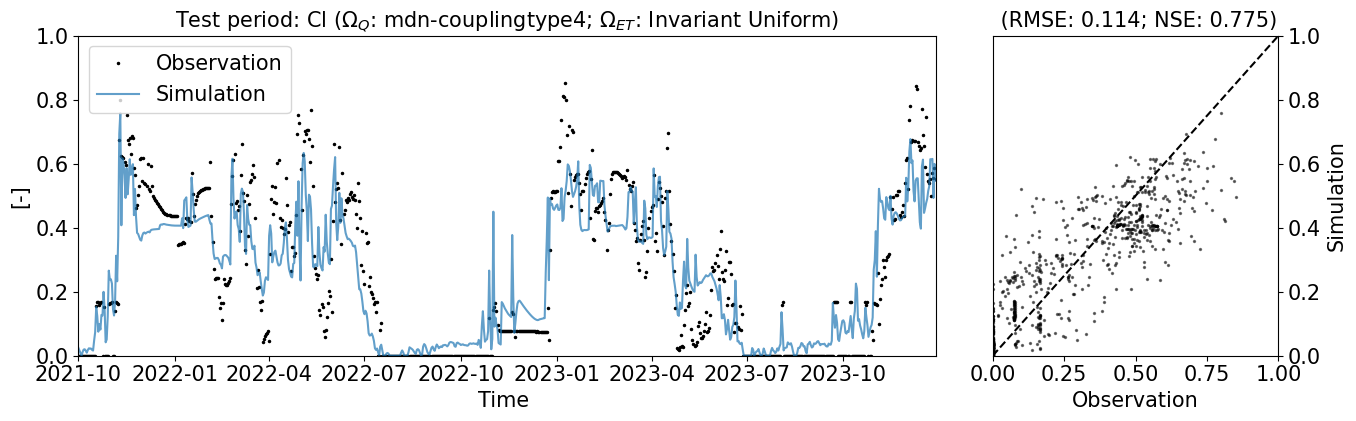

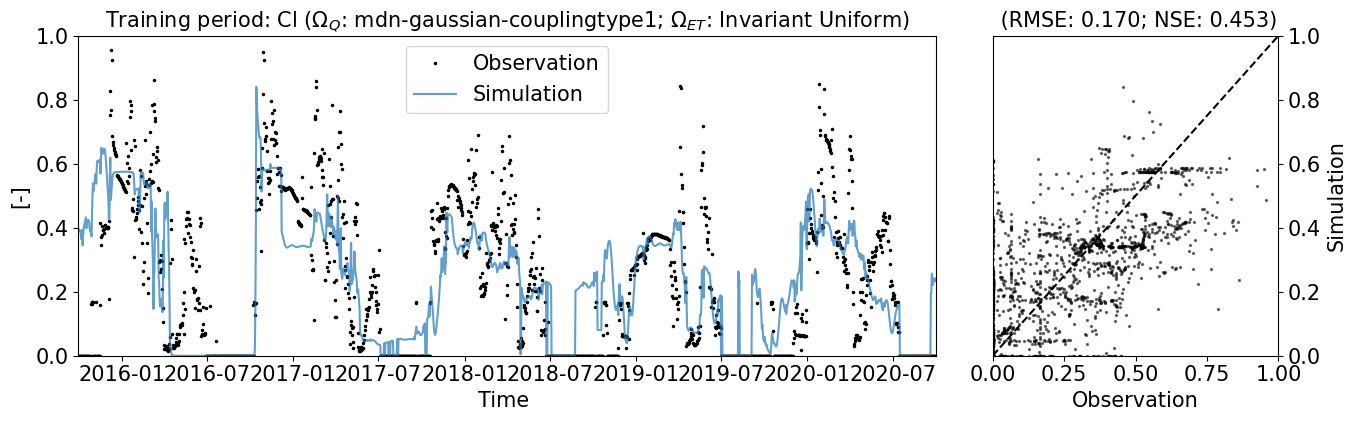

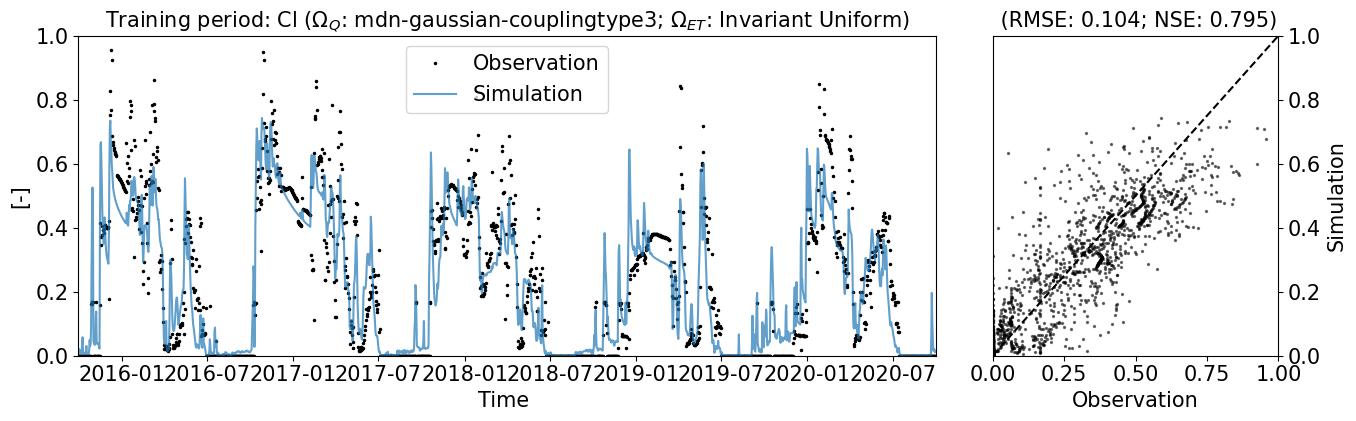

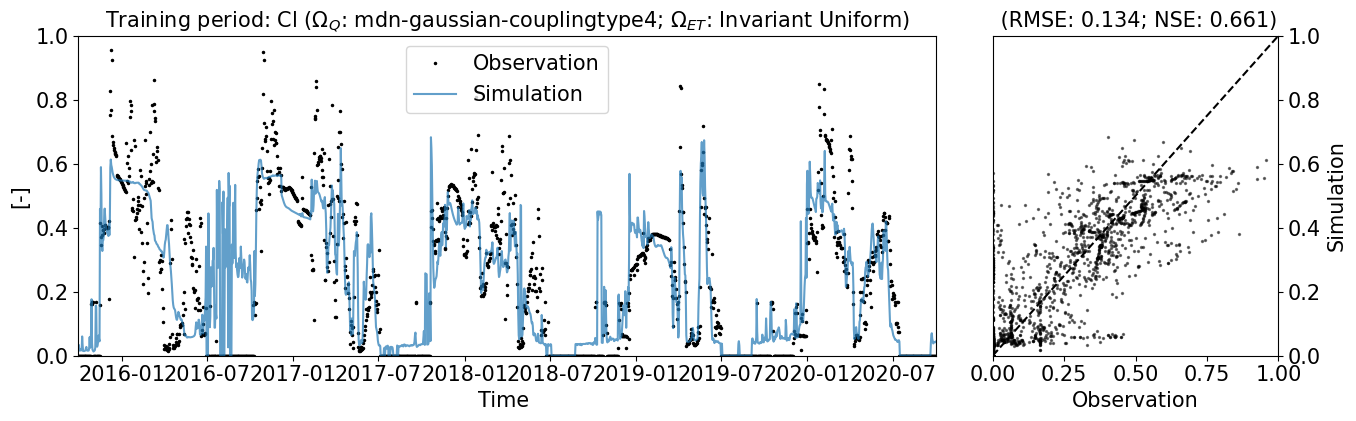

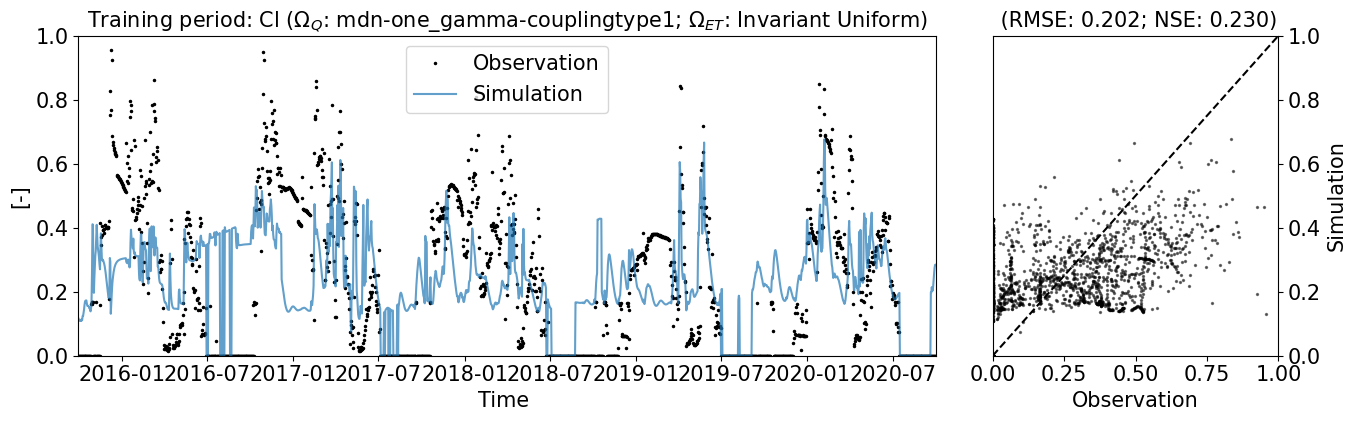

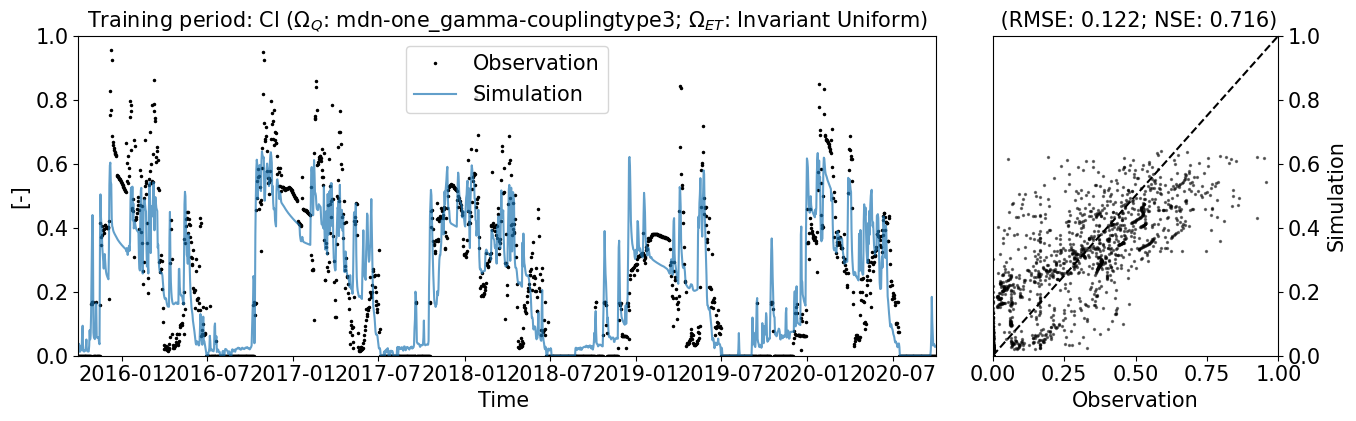

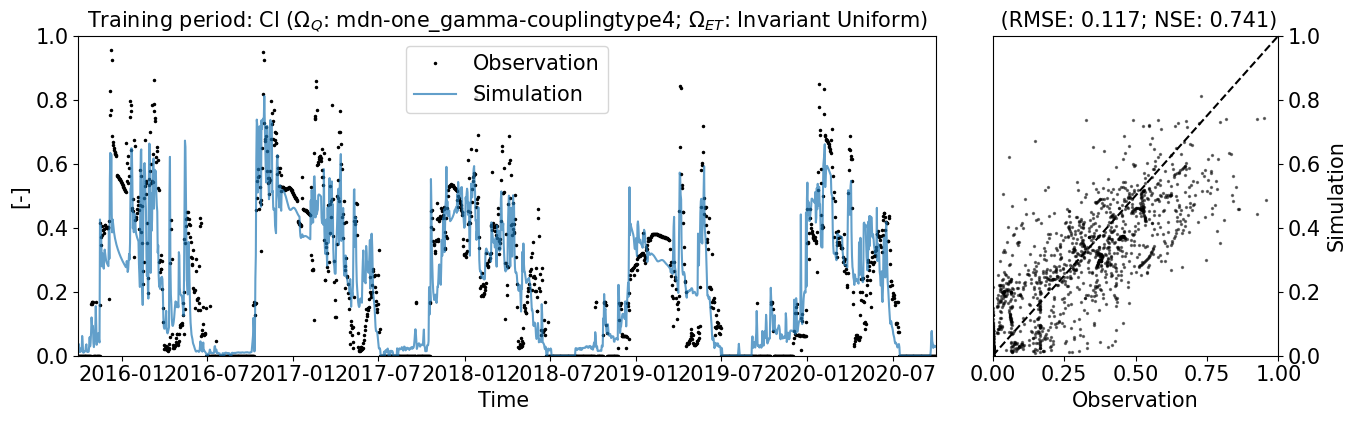

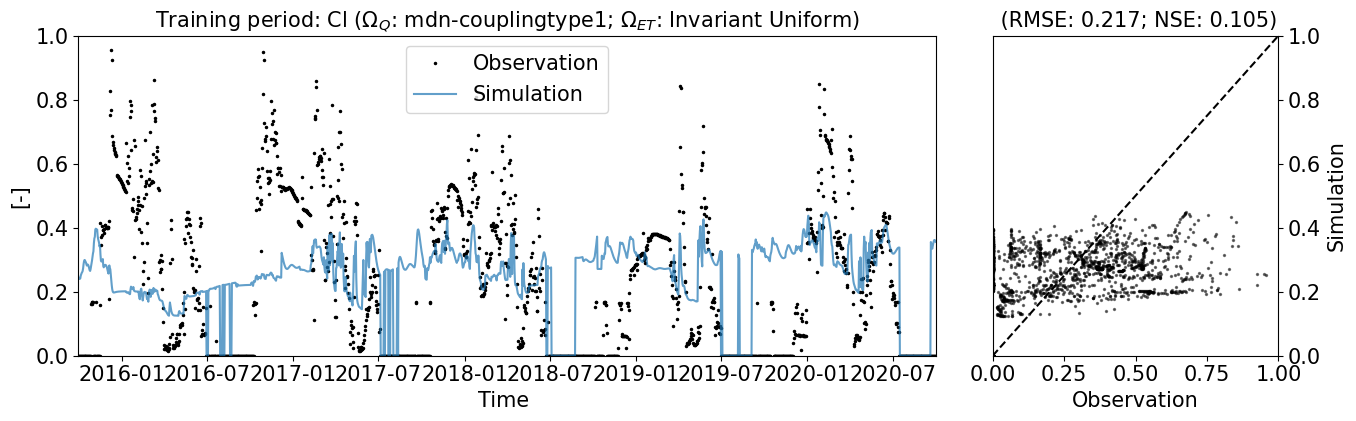

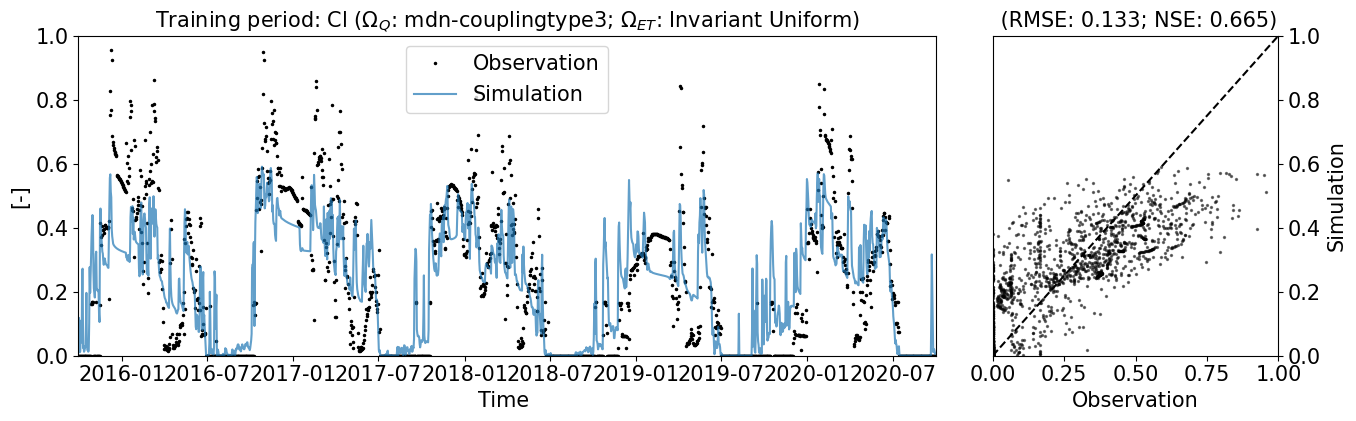

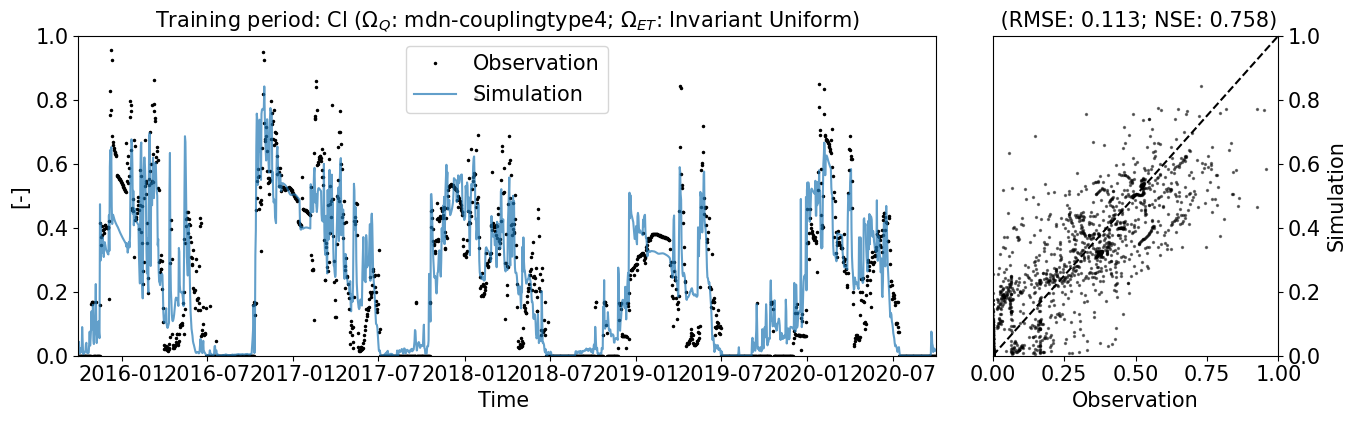

In [27]:
# Performance on training and test
for i,df in enumerate(df_set):
    model_name = model_names[i]
    # Plot the C_J simulation
    plot_timeseries_obs_1to1(
        obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_sim'].values, lim=[0,1], timesteps=df[test_s:test_e].index,
        varn=f'Test period: Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
    );

for i,df in enumerate(df_set):
    model_name = model_names[i]
    # Plot the C_J simulation
    plot_timeseries_obs_1to1(
        obs=df[train_s:train_e]['C_Q'].values, sim=df[train_s:train_e]['C_Q_sim'].values, lim=[0,1], timesteps=df[train_s:train_e].index,
        varn=f'Training period: Cl ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
    );


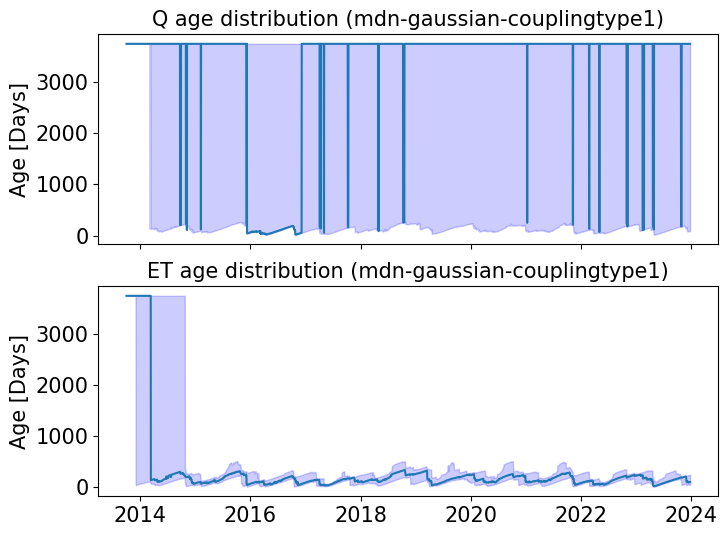

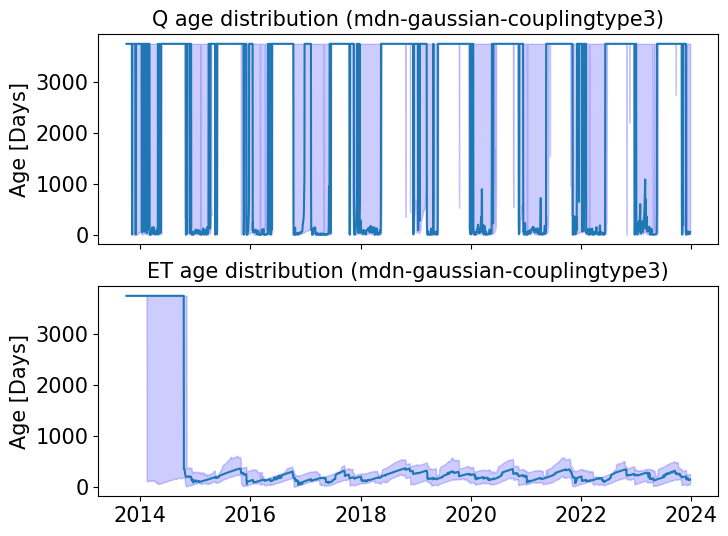

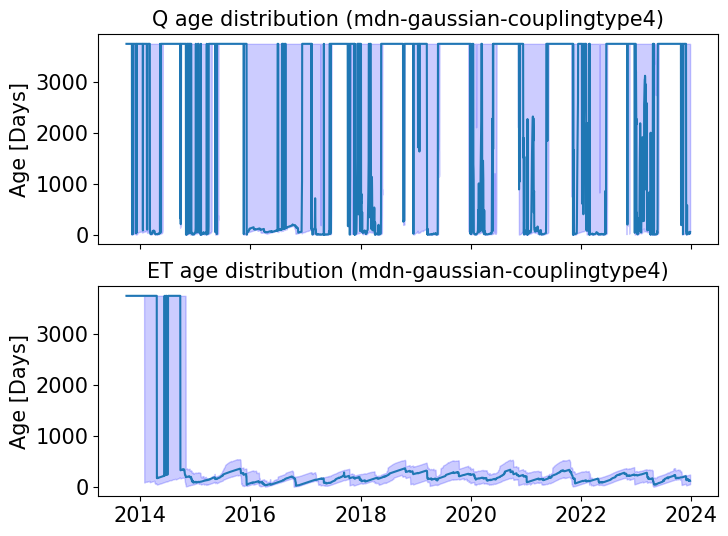

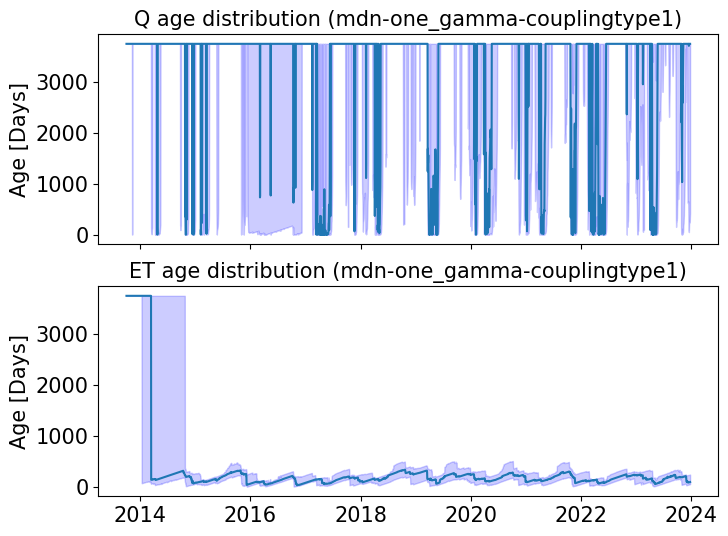

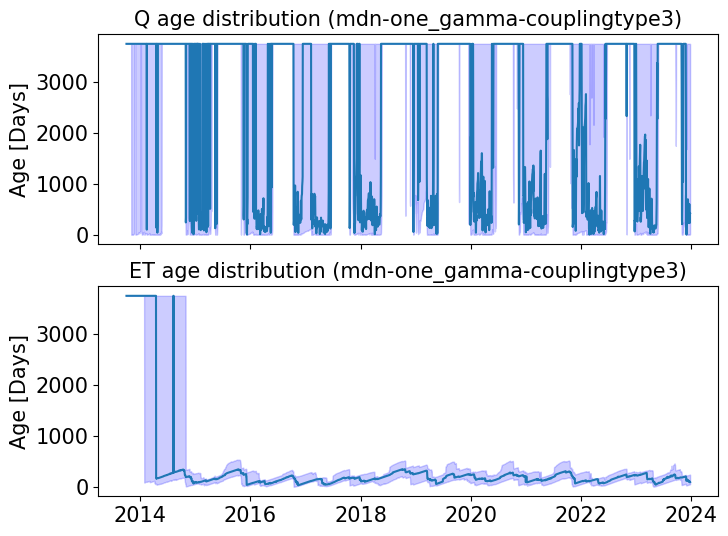

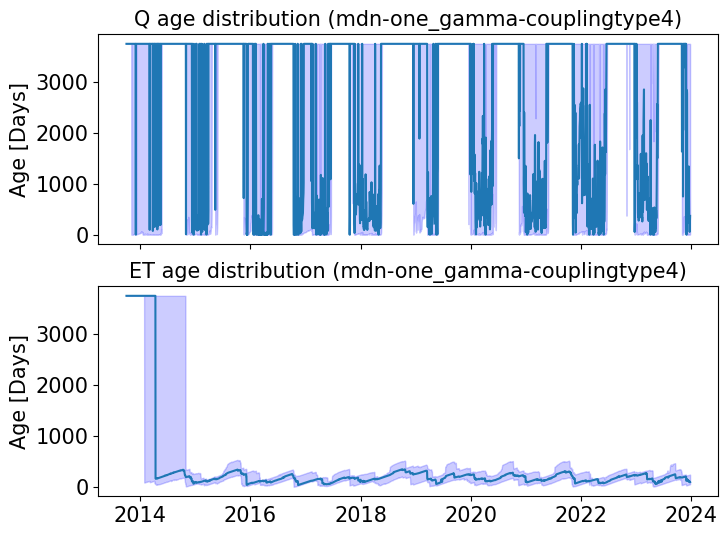

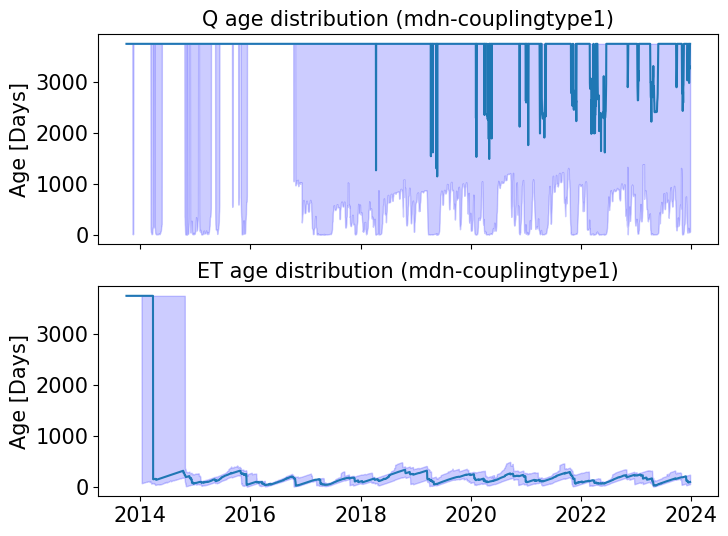

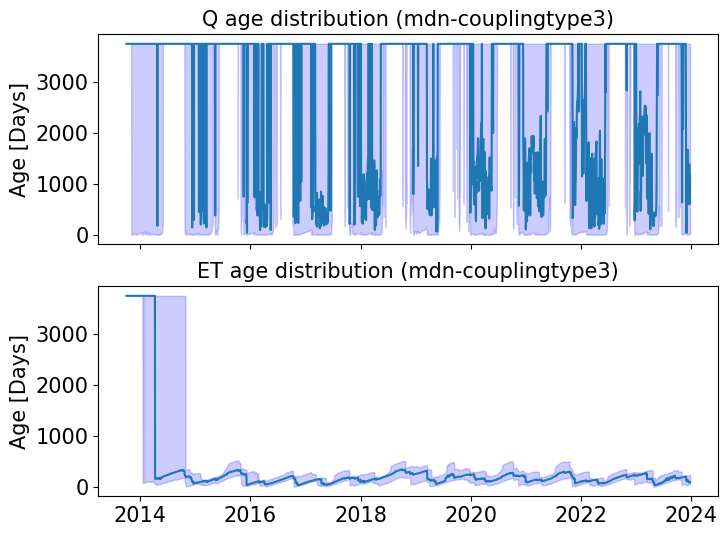

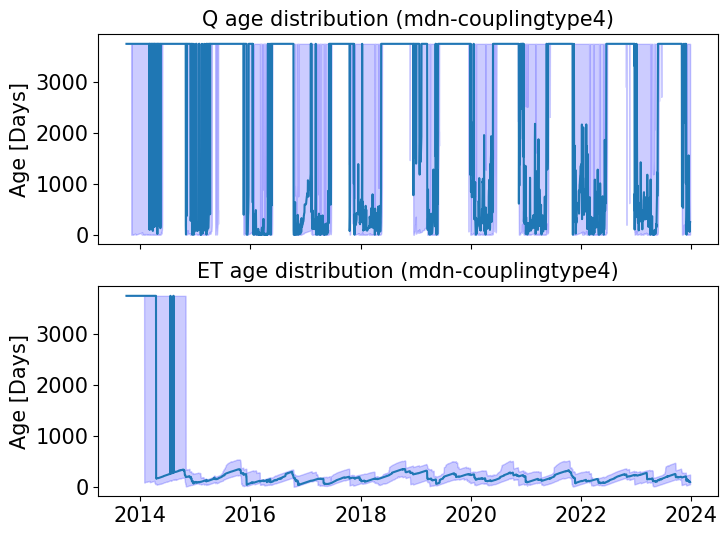

In [28]:
# Mean age
for i,model_name in enumerate(model_names):
    J, Q, ET, C_J, C_Q_obs, time = transport_data_set[i]
    sT, mT, mQETs, pQETs, mRs, C_Q = transport_output_set[i]
    # Plot the age distribution
    axes = plot_PQET_quantile(pQETs, dt, time, figsize=(8,6), label=model_name)
    # axes = plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=1000, figsize=(8,6));


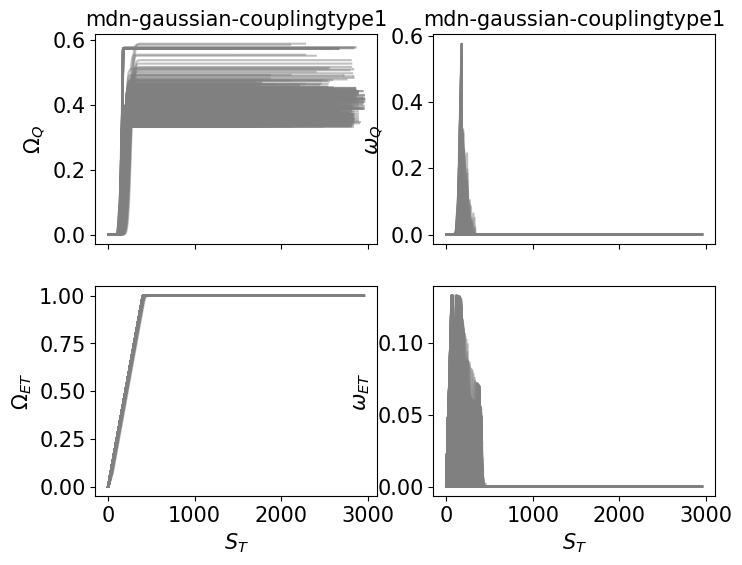

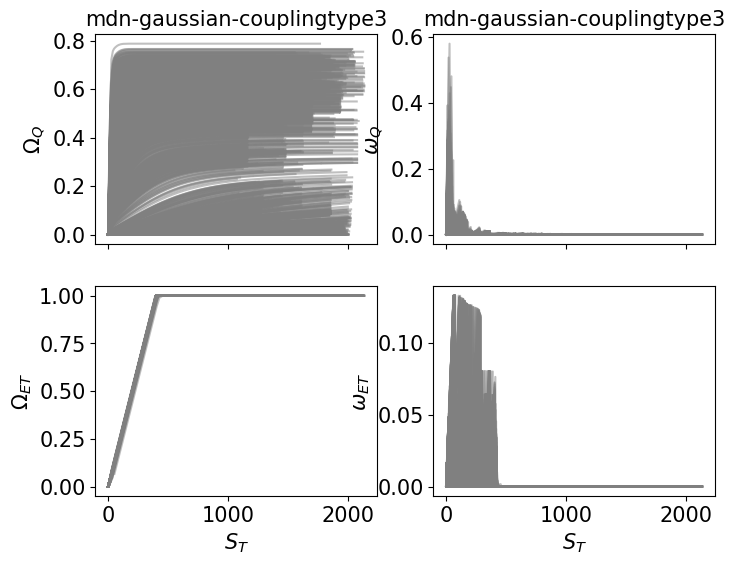

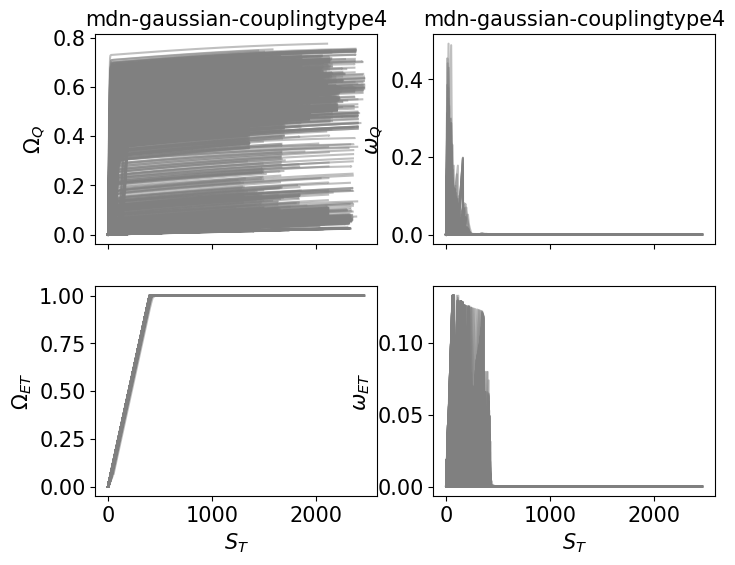

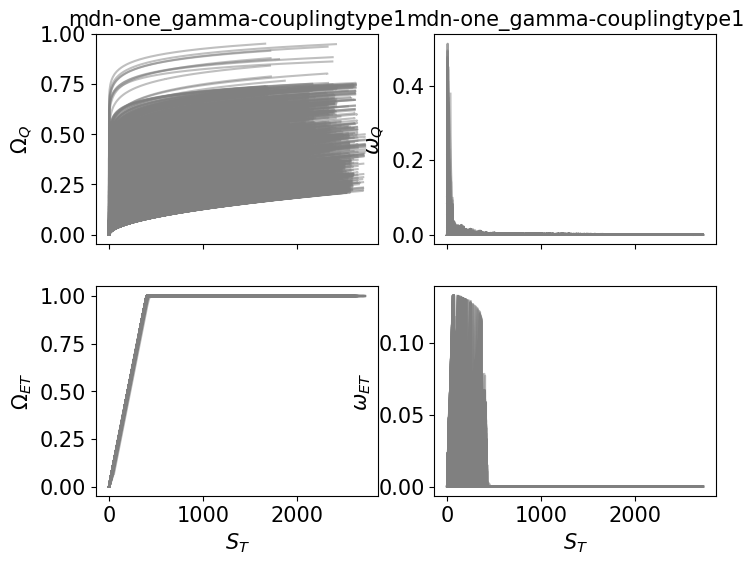

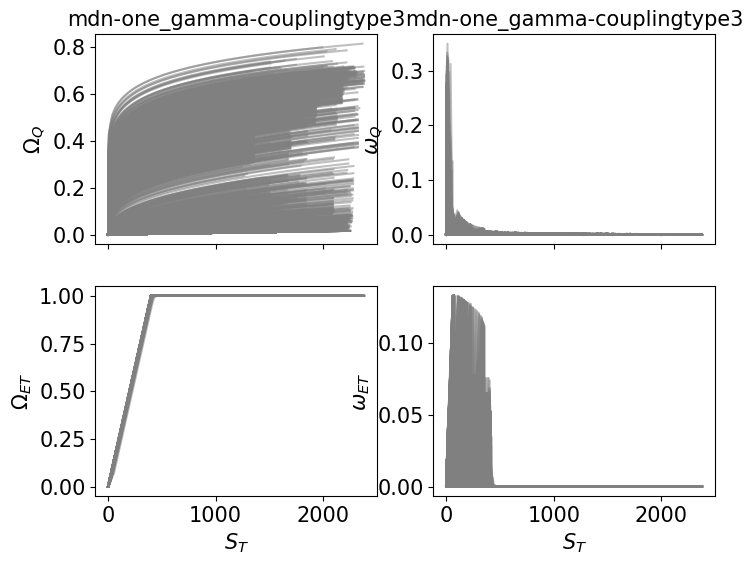

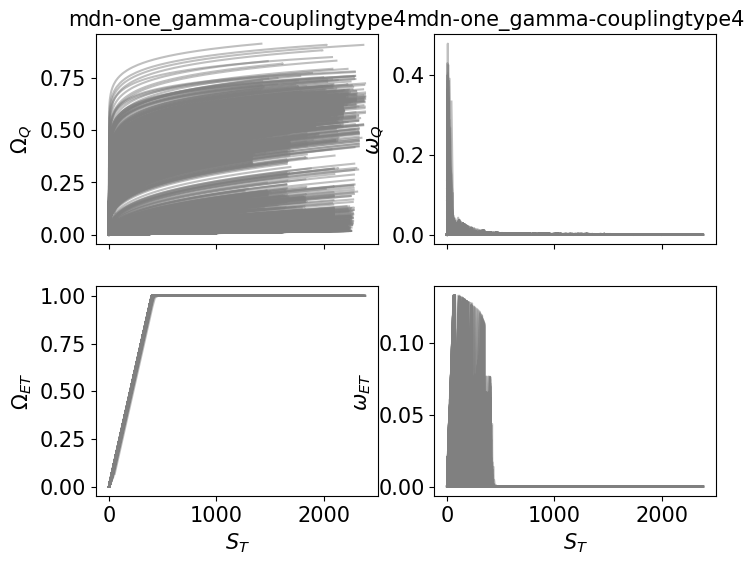

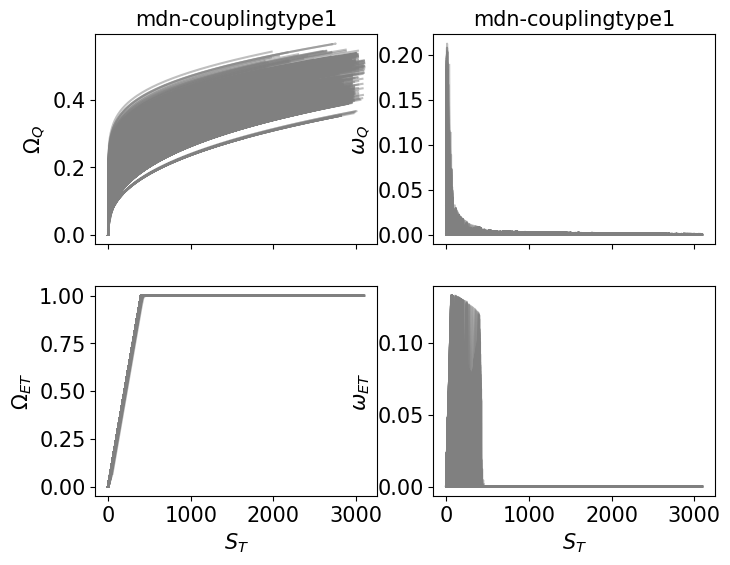

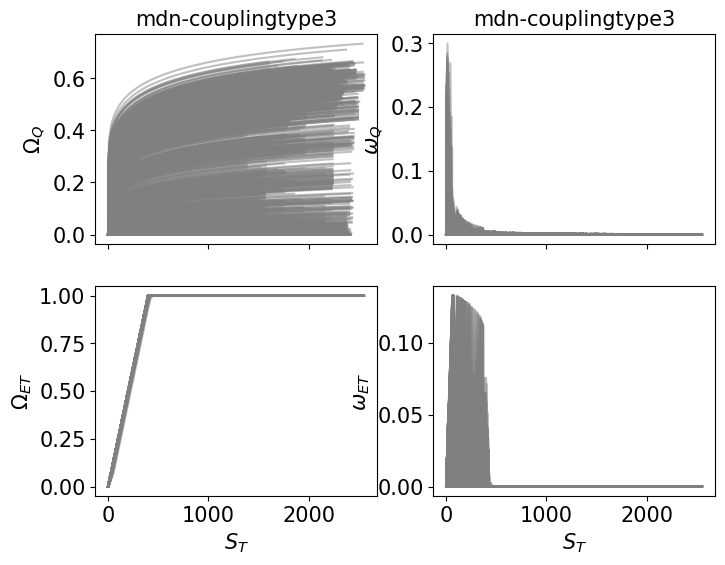

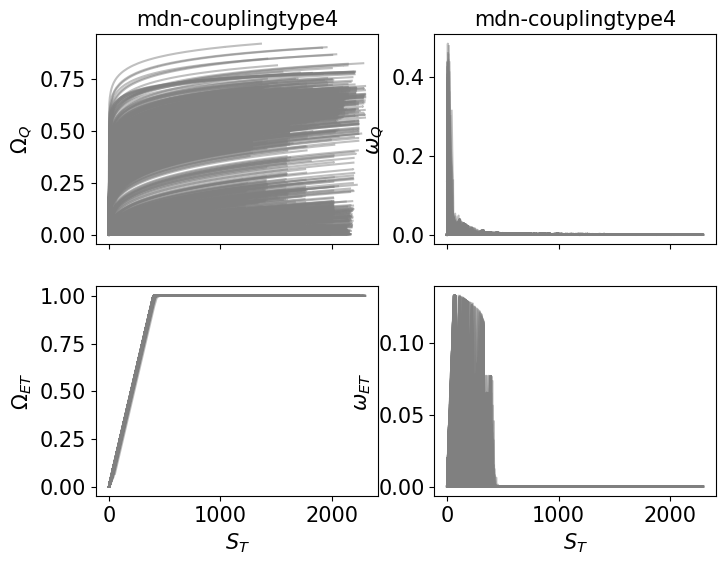

In [29]:
# Age distribution
for i,model_name in enumerate(model_names):
    sT, mT, mQETs, pQETs, mRs, C_Q = transport_output_set[i]
    axes = plot_PQET_ST2(sT, pQETs, dt, last_age_cut=2000, figsize=(8,6), label=model_name)
    

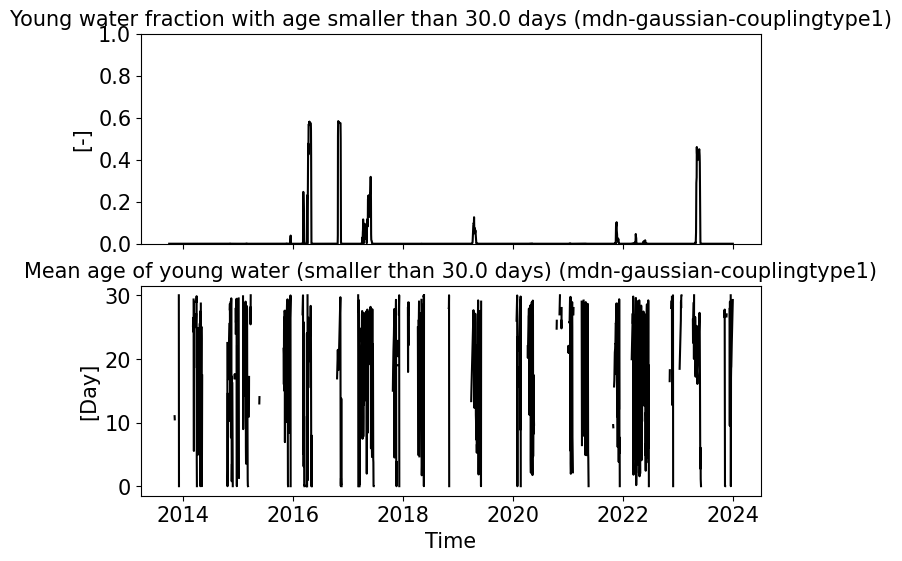

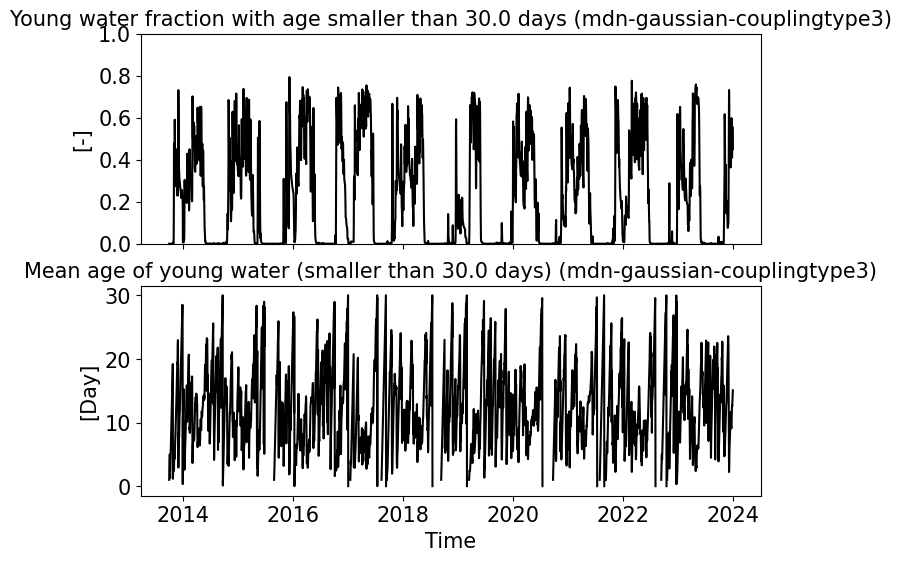

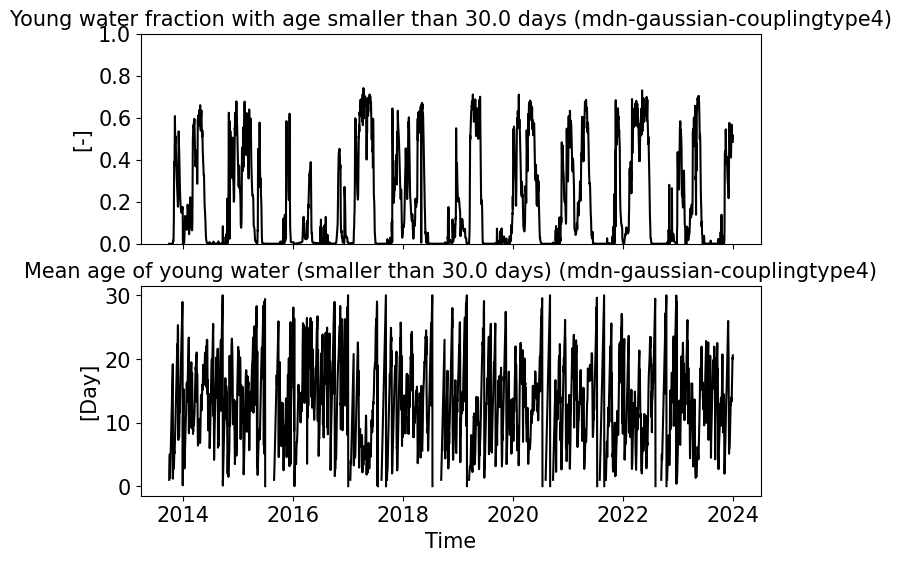

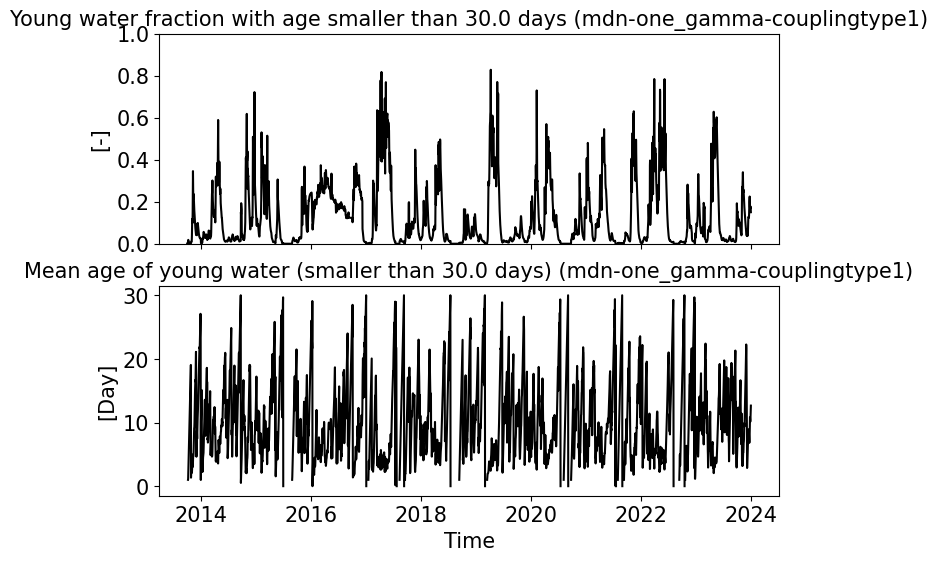

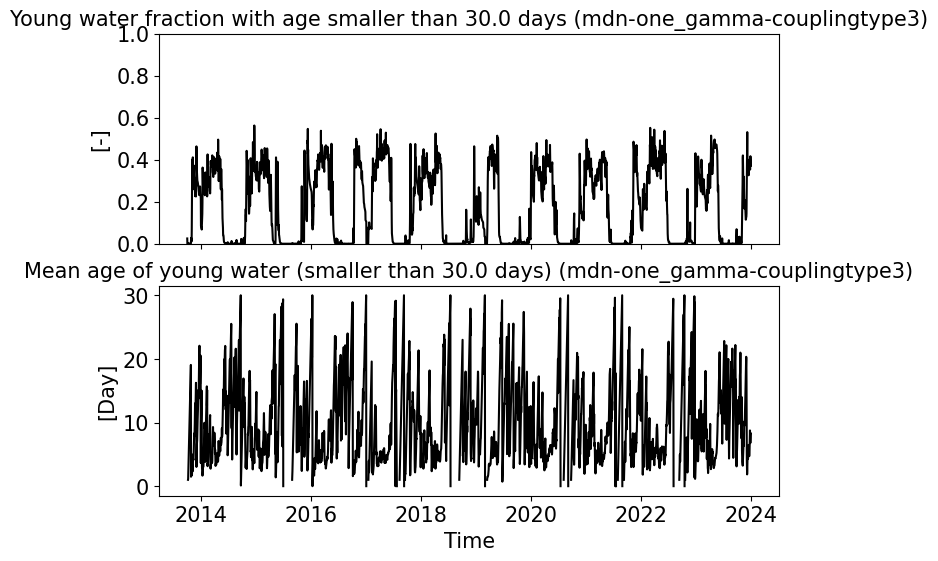

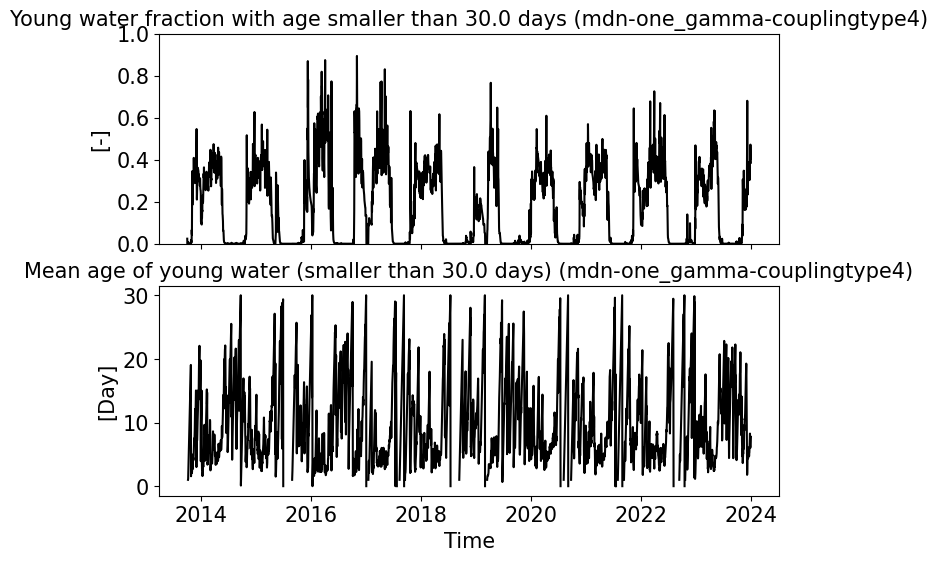

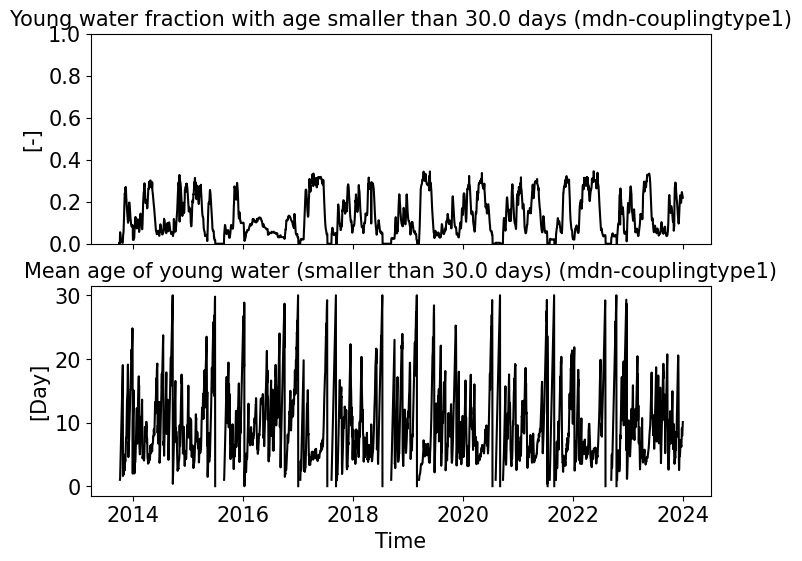

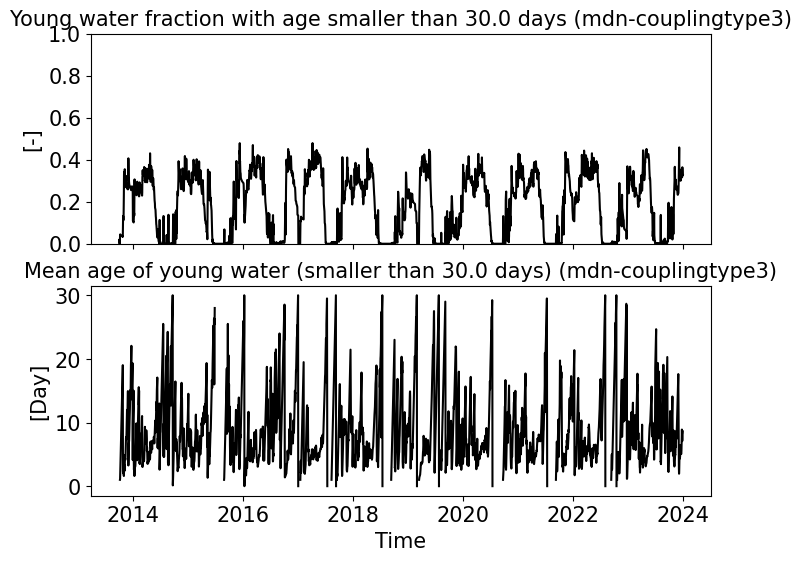

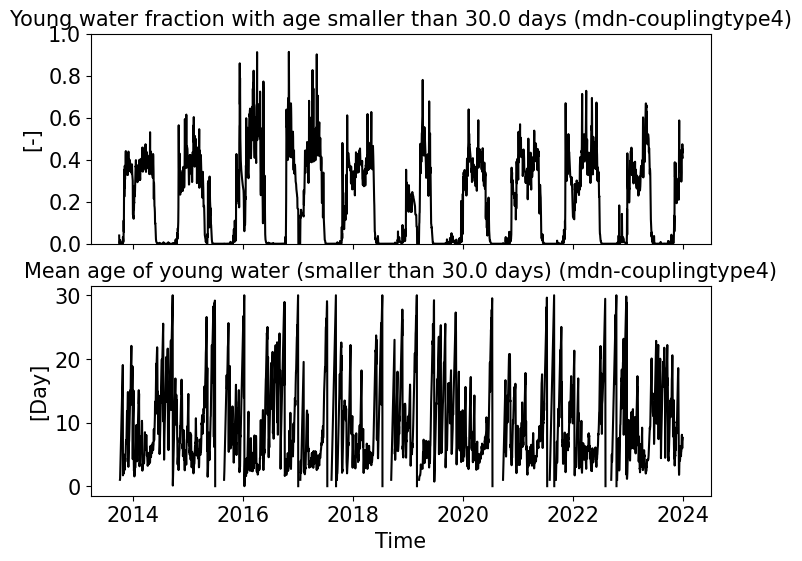

In [30]:
# Young water fraction in streamflow
for i,model_name in enumerate(model_names):
    sT, mT, mQETs, pQETs, mRs, C_Q = transport_output_set[i]
    axes = plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=30, label=model_name)
